### Célula 1: Configuração do Ambiente e Arquitetura Modular
Importação das bibliotecas base e carregamento dos nossos módulos internos (`core` e `utils`). A modularização mantém o notebook focado apenas na orquestração e análise visual da estratégia.

In [129]:
# Core libraries
import importlib
import numpy as np
from itertools import combinations

# Utilities
import warnings
warnings.filterwarnings("ignore")

# Variables
import config as cfg
importlib.reload(cfg)

import core.analyse as an
importlib.reload(an)

import core.dataset as dt
importlib.reload(dt)

import core.models as model
importlib.reload(model)

import core.backtest as backT
importlib.reload(backT)

import utils.metrics as metric
importlib.reload(metric)

import utils.io as io
importlib.reload(io)

<module 'utils.io' from 'c:\\Users\\Asus\\Desktop\\Git\\master-projects\\financial-market-analysis\\src\\utils\\io.py'>

### Célula 2: Extração de Dados de Mercado
Recolha das cotações históricas diárias (via `yfinance` ou API equivalente) para o universo de ativos (*Tickers*) previamente definido no ficheiro de configuração.

In [130]:
if cfg.DOWNLOAD_STOCKS is True:
    prices = io.get_stock_data(cfg.TICKERS)
    print("All data downloaded.")

### Célula 3: Divisão Temporal (Look-Ahead Bias Prevention)
Separação estrita dos dados em dois períodos: Formação (2016-2023) para treino dos modelos e descoberta de relações estatísticas, e Trading/Testing (2024-2026) para simulação num ambiente cego (*Out-of-Sample*).

In [131]:
# Prevenir Look-Ahead Bias
prices = prices.dropna()
prices_formation = prices.loc[cfg.TRAIN_START:cfg.TRAIN_END]
prices_trading = prices.loc[cfg.TEST_START:cfg.TEST_END]

print(f"Formação: {cfg.TRAIN_START} a {cfg.TRAIN_END} ({prices_formation.shape[0]} dias)")
print(f"Teste: {cfg.TEST_START} a {cfg.TEST_END} ({prices_trading.shape[0]} dias)")

Formação: 2022-01-01 a 2025-12-31 (1002 dias)
Teste: 2008-01-01 a 2020-12-31 (3159 dias)


### Célula 4: Cálculo de Retornos (Período de Formação)
Cálculo dos retornos percentuais diários aplicados exclusivamente aos dados de formação, garantindo que o motor de descoberta não tem acesso a volatilidade futura.

In [132]:
# Calculamos os retornos APENAS nos dados de Formação
returns_formation = prices_formation.pct_change().dropna()
returns_formation.head()

Ticker,A,AAPL,ABT,ACGL,ACN,ADBE,ADI,ADM,ADP,ADSK,...,WSM,WST,WTW,WY,WYNN,XEL,XOM,YUM,ZBH,ZBRA
Date,,,,,,,,,,,,,,,,,,,,,
2022-01-04,-0.033806,-0.012692,-0.023519,0.013019,-0.007146,-0.018374,-0.009032,0.018560,0.004672,-0.019491,...,-0.017706,-0.037944,0.013160,0.012817,-0.003190,0.006329,0.037614,0.005347,0.010145,0.006337
2022-01-05,-0.017131,-0.026600,-0.004493,-0.011744,-0.017611,-0.071426,-0.015437,-0.007809,-0.008525,-0.049858,...,-0.071196,-0.058345,-0.006955,-0.024823,-0.037033,0.009800,0.012438,-0.012677,-0.003296,-0.050068
2022-01-06,0.003499,-0.016693,-0.000148,0.005830,-0.048290,-0.000603,0.003183,0.008891,-0.006871,-0.000795,...,0.016486,0.009332,-0.011265,0.007986,0.004629,-0.007821,0.023520,0.010330,-0.008307,-0.005410
2022-01-07,-0.026623,0.000988,0.003108,0.004681,-0.019180,-0.006652,-0.026242,0.008524,-0.010564,-0.006777,...,-0.036715,-0.042355,-0.011863,-0.001238,-0.001063,0.008759,0.008197,-0.011466,-0.006050,-0.043771
2022-01-10,0.000069,0.000116,-0.002213,0.021078,0.006069,0.029626,0.009240,0.001719,-0.024912,0.000267,...,0.007026,0.005378,0.004578,-0.004710,-0.028149,0.010999,-0.005952,-0.013964,-0.009754,0.008571


### Célula 5: Descoberta de Pares (RMT e HDBSCAN)
Filtragem matemática do ruído do mercado usando a Teoria das Matrizes Aleatórias (RMT) de Marchenko-Pastur, seguida da aplicação do algoritmo HDBSCAN para encontrar *clusters* de ações estruturalmente correlacionadas.

Total de ações (N): 416 | Total de dias (T): 1001
Limite de Ruído Marchenko-Pastur (lambda_max): 2.7049
-> Componentes Principais Retidos (Sinal Puro): 14


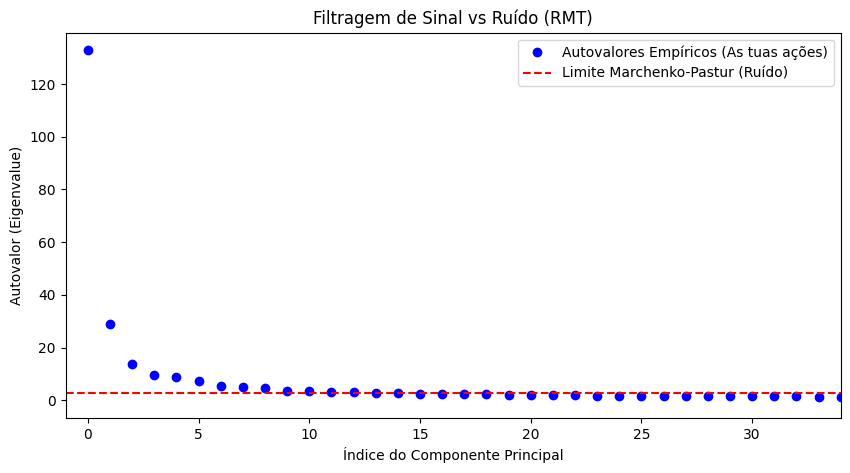

Resumo do HDBSCAN:
-> 85 clusters estruturais encontrados.
-> 121 ações rejeitadas como ruído.



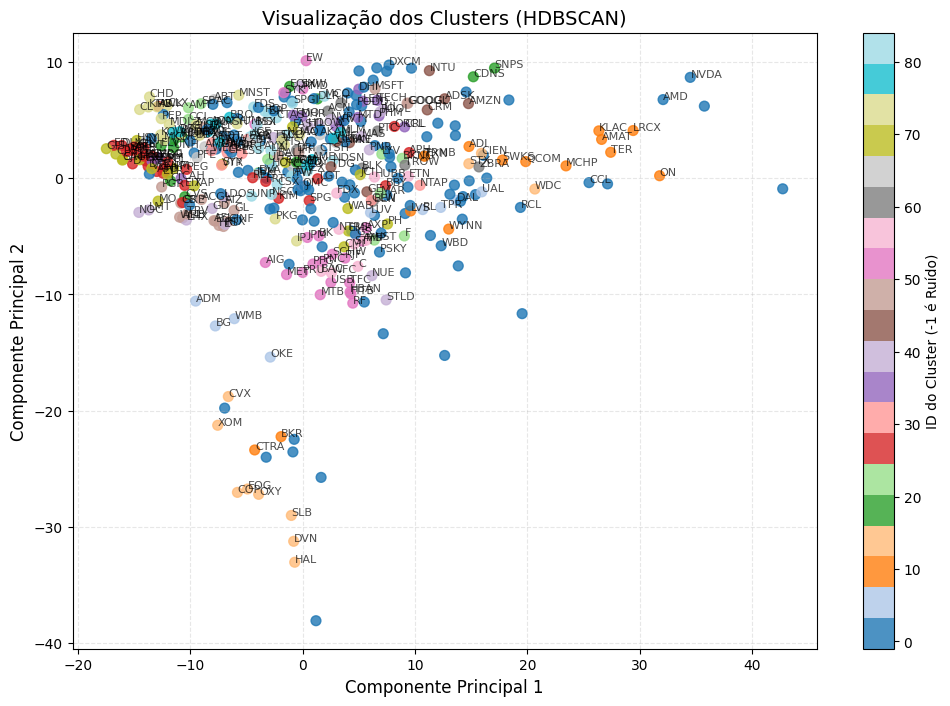


Pares Candidatos Extraídos: 799


In [133]:
# 1. Filtro de Ruído Institucional (Marchenko-Pastur)
X_pca_sota = an.calculate_RMT(returns_formation)

# 2. Aplicar o HDBSCAN (Ajusta-se automaticamente às densidades)
pairs_grouped, clusters_dict = an.RMT_clustering_hdbscan(X_pca_sota, returns_formation)

# 3. Extrair todas as combinações (2 a 2) dentro dos clusters encontrados
candidate_pairs = []
for cluster_list in clusters_dict.values():
    if len(cluster_list) > 1:
        for combo in combinations(cluster_list, 2):
            candidate_pairs.append(list(combo))

print(f"\nPares Candidatos Extraídos: {len(candidate_pairs)}")

### Célula 6: Validação Estrutural (Cointegração e Elasticidade)
Filtra as combinações candidatas garantindo estacionariedade forte (Teste ADF) e velocidade de reversão rápida (Expoente de Hurst < 0.4). O *Hedge Ratio* (Beta) de cada par é calculado recorrendo ao método simétrico de *Total Least Squares* (TLS).

In [134]:
print(f"A testar {len(candidate_pairs)} pares candidatos (TLS + ADF + Hurst)...")
valid_pairs_df, spreads_dict = an.validate_pairs(candidate_pairs, prices_formation, prices)

print(f"-> Sobreviveram {len(valid_pairs_df)} pares institucionais!")
display(valid_pairs_df.head(10))

A testar 799 pares candidatos (TLS + ADF + Hurst)...
-> Sobreviveram 14 pares institucionais!


,ativo_y,ativo_x,beta_tls,adf_p_value,hurst
10,GOOG,GOOGL,1.000023,0.001370,0.278194
11,LII,TSCO,2.839766,0.011272,0.359325
9,GD,LDOS,0.596087,0.001618,0.366347
5,BDX,DGX,-0.731734,0.000071,0.369765
2,AEP,CMS,1.266844,0.014754,0.375799
13,PNR,TSCO,2.219612,0.006666,0.377012
6,FITB,PNC,1.130427,0.000056,0.380422
12,NVR,TSCO,1.758957,0.012138,0.382117
4,FE,SRE,0.932435,0.034971,0.386755
7,HBAN,RF,1.132132,0.023291,0.392824


### Célula 7: Feature Engineering e Tripla Barreira
Modelação da física diária do *spread*. Calcula métricas como a ECDF (anomalias de preço) e os parâmetros de *Ornstein-Uhlenbeck* (velocidade, centro de gravidade e meia-vida). Por fim, aplica o Método da Tripla Barreira para rotular os sinais históricos como Sucesso (1) ou Fracasso (0) para treino supervisionado.

In [135]:
print(f"A processar pares institucionais. Isto pode demorar...")
global_meta_dataset = dt.build_global_dataset(
    valid_pairs_df, 
    spreads_dict, 
    cfg.TRAIN_START,
    cfg.TRAIN_END,
    cfg.WINDOW, 
    cfg.LOWER_PERCENTILE, 
    cfg.UPPER_PERCENTILE, 
    cfg.SL_MULTIPLIER
)

# CRIAR A PASTA DE RESULTADOS AQUI
save_dir = io.setup_results_dir(cfg)

# Guardar o dataset base para efeitos de auditoria
global_meta_dataset.to_csv(f"{save_dir}/dataset_treino.csv")

print(f"\n--- DATASET GLOBAL CONSTRUÍDO ---")
print(f"Total Trades Históricos: {len(global_meta_dataset)}")
if not global_meta_dataset.empty:
    print(f"Win-Rate Agente Base: {(global_meta_dataset['target'].mean() * 100):.2f}%")

A processar pares institucionais. Isto pode demorar...


100%|██████████| 14/14 [00:21<00:00,  1.56s/it]

-> Diretório de resultados criado: ../results/Train_2022-01-01_to_2025-12-31__Test_2008-01-01_to_2020-12-31

--- DATASET GLOBAL CONSTRUÍDO ---
Total Trades Históricos: 306
Win-Rate Agente Base: 23.53%


### Célula 8: O Meta-Agente (Treino SOTA)
Treino do modelo preditivo de *Machine Learning* (Ensemble). Utiliza *TimeSeriesSplit* com *Embargo* (Purged K-Fold) para prevenir o vazamento de informação temporal (*Data Leakage*), extraindo a importância que o modelo dá a cada variável.

In [136]:
# 1. Treino do Modelo Global
if cfg.TRAIN_MODELS is True:
    meta_agent_global, cv_scores, importances = model.train_meta_agent(global_meta_dataset)

    # 2. Treino dos Modelos Específicos
    specific_agents_dict = model.train_specific_agents(global_meta_dataset)

print("=== VALIDAÇÃO CRUZADA GLOBAL (Meta-Agente) ===")
print(f"Accuracy Preditiva: {cv_scores.mean():.2f} (+/- {cv_scores.std():.2f})")
print("\n-> Importância das Variáveis:")
print(importances)

-> 14 Modelos Específicos treinados com sucesso.
=== VALIDAÇÃO CRUZADA GLOBAL (Meta-Agente) ===
Accuracy Preditiva: 0.64 (+/- 0.08)

-> Importância das Variáveis:
theta         0.349636
half_life     0.328267
volatility    0.270395
ecdf          0.034939
side          0.016763
dtype: float64


### Célula 9: Análise de Risco (Threshold Tuning)
Ajuste interativo do limiar de exigência probabilística do Meta-Agente. Permite ao analista quantitativo decidir o ponto ótimo de equilíbrio entre o número de trades gerados (*Recall*) e a fiabilidade estatística (*Precision*).

In [137]:
# 1. Prever as probabilidades no dataset global usando o Modelo Global
X_global = global_meta_dataset[['ecdf', 'theta', 'half_life', 'volatility', 'side']]
global_meta_dataset['Prob_Sucesso_Global'] = meta_agent_global.predict_proba(X_global)[:, 1]

probs_sucesso = global_meta_dataset['Prob_Sucesso_Global']
y_real = global_meta_dataset['target']

print("=== ANÁLISE DE CONFIANÇA DO PORTÃO 2 (MODELO GLOBAL) ===")
df_thresholds = metric.tune_threshold(probs_sucesso, y_real, thresholds=np.arange(0.5, 0.9, 0.05))
display(df_thresholds)

# Gravar a análise de limiares e as importâncias na nossa pasta de resultados
df_thresholds.to_csv(f"{save_dir}/threshold_analysis_global.csv", index=False)
importances.to_csv(f"{save_dir}/feature_importances_global.csv")

# Gravar a autorização no dataset
global_meta_dataset['Trade_Autorizado'] = (global_meta_dataset['Prob_Sucesso_Global'] >= cfg.LIMIAR_FINAL).astype(int)

print(f"\n-> Usando o Limiar de {cfg.LIMIAR_FINAL*100}%, o bot autorizou {global_meta_dataset['Trade_Autorizado'].sum()} trades durante o período de formação.")

# Atualizar o ficheiro do dataset de treino com as novas colunas de probabilidade
global_meta_dataset.to_csv(f"{save_dir}/dataset_treino.csv")

=== ANÁLISE DE CONFIANÇA DO PORTÃO 2 (MODELO GLOBAL) ===


,Limiar (%),Trades Aprovados,Precision (Win-Rate),Recall (Oportunidades)
0,50%,104,43.3%,62.5%
1,55%,79,50.6%,55.6%
2,60%,49,59.2%,40.3%
3,65%,29,65.5%,26.4%
4,70%,20,70.0%,19.4%
5,75%,16,75.0%,16.7%
6,80%,6,100.0%,8.3%
7,85%,0,0.0%,0.0%



-> Usando o Limiar de 70.0%, o bot autorizou 20 trades durante o período de formação.


### Célula 10: Motor de Backtest Institucional (Out-of-Sample)
Simulação *Walk-Forward* no período 2024-2026. O motor avalia os sinais do Agente Base, requer autorização ao Meta-Agente, calcula a exposição usando o Critério de Kelly com alavancagem de 3x, e fecha posições dinamicamente através da Tripla Barreira.

In [138]:
print("=== BACKTEST 1: MODELO GLOBAL ===")
trades_global = backT.run_oos_backtest(
    valid_pairs_df=valid_pairs_df, spreads_dict=spreads_dict, 
    models_dict={'global': meta_agent_global}, mode='global',
    test_start=cfg.TEST_START, test_end=cfg.TEST_END,
    window=cfg.WINDOW, lower_pct=cfg.LOWER_PERCENTILE, upper_pct=cfg.UPPER_PERCENTILE, 
    sl_mult=cfg.SL_MULTIPLIER, limiar_final=cfg.LIMIAR_FINAL, alavancagem_fundo=cfg.ALAVANCAGEM_FUNDO
)

if not trades_global.empty:
    trades_global.to_csv(f"{save_dir}/trades_global.csv", index=False)

    print(f"\nNo modo Global-Testing executou {len(trades_global)} trades.")
    win_rate_global = len(trades_global[trades_global['exit_reason'] == 'Take-Profit']) / len(trades_global) * 100
    print(f"Win-Rate Global-Testing: {win_rate_global:.2f}%")

print("\n=== BACKTEST 2: MODELOS ESPECÍFICOS ===")
trades_specific = backT.run_oos_backtest(
    valid_pairs_df=valid_pairs_df, spreads_dict=spreads_dict, 
    models_dict=specific_agents_dict, mode='specific',
    test_start=cfg.TEST_START, test_end=cfg.TEST_END,
    window=cfg.WINDOW, lower_pct=cfg.LOWER_PERCENTILE, upper_pct=cfg.UPPER_PERCENTILE, 
    sl_mult=cfg.SL_MULTIPLIER, limiar_final=cfg.LIMIAR_FINAL, alavancagem_fundo=cfg.ALAVANCAGEM_FUNDO
)

if not trades_specific.empty:
    trades_specific.to_csv(f"{save_dir}/trades_specific.csv", index=False)

    print(f"\nNo modo Specific-Testing executou {len(trades_specific)} trades.")
    win_rate_specific = len(trades_specific[trades_specific['exit_reason'] == 'Take-Profit']) / len(trades_specific) * 100
    print(f"Win-Rate Specific-Testing: {win_rate_specific:.2f}%")

print("\n=== BACKTEST 3: CROSS-TESTING (TRANSFER LEARNING) ===")
trades_cross = backT.run_oos_backtest(
    valid_pairs_df=valid_pairs_df, spreads_dict=spreads_dict, 
    models_dict=specific_agents_dict, mode='cross_testing',
    test_start=cfg.TEST_START, test_end=cfg.TEST_END,
    window=cfg.WINDOW, lower_pct=cfg.LOWER_PERCENTILE, upper_pct=cfg.UPPER_PERCENTILE, 
    sl_mult=cfg.SL_MULTIPLIER, limiar_final=cfg.LIMIAR_FINAL, alavancagem_fundo=cfg.ALAVANCAGEM_FUNDO
)

if not trades_cross.empty:
    trades_cross.to_csv(f"{save_dir}/trades_cross_testing.csv", index=False)
    
    # Se quiseres ver rapidamente as estatísticas do Cross-Testing:
    print(f"\nNo modo Cross-Testing executou {len(trades_cross)} trades.")
    win_rate_cross = len(trades_cross[trades_cross['exit_reason'] == 'Take-Profit']) / len(trades_cross) * 100
    print(f"Win-Rate Cross-Testing: {win_rate_cross:.2f}%")



=== BACKTEST 1: MODELO GLOBAL ===


OOS Backtest (GLOBAL): 100%|██████████| 14/14 [02:34<00:00, 11.06s/it]



No modo Global-Testing executou 247 trades.
Win-Rate Global-Testing: 21.86%

=== BACKTEST 2: MODELOS ESPECÍFICOS ===


OOS Backtest (SPECIFIC): 100%|██████████| 14/14 [02:20<00:00, 10.00s/it]



No modo Specific-Testing executou 48 trades.
Win-Rate Specific-Testing: 16.67%

=== BACKTEST 3: CROSS-TESTING (TRANSFER LEARNING) ===


OOS Backtest (CROSS_TESTING): 100%|██████████| 14/14 [02:11<00:00,  9.36s/it]


No modo Cross-Testing executou 4 trades.
Win-Rate Cross-Testing: 25.00%


### Célula 11: Relatório de Performance (Quant Tearsheet)
Avaliação final da rentabilidade e risco da estratégia. Compila o registo de operações num relatório detalhado (Win-Rate, Risco/Recompensa, taxas de paragem) e gera visualizações da Curva de Capital (*Equity Curve*) e respetivo *Drawdown* máximo histórico.


=== ANÁLISE COMPARATIVA SOTA (TRÊS ABORDAGENS) ===

=== RESUMO DE PERFORMANCE (OUT-OF-SAMPLE) ===
                    Modelo Global  Modelos Específicos  Cross-Testing
Total Trades               247.00                48.00           4.00
Win-Rate (%)                21.86                16.67          25.00
Stop-Loss Rate (%)          28.74                27.08           0.00
Time-Stop Rate (%)          49.39                56.25          75.00
Lucro Médio (%)              1.25                 2.59           2.41
Perda Média (%)             -1.12                -1.66          -1.10
Risco/Recompensa             1.12                 1.56           2.20
Retorno Total (%)          -11.76                 3.17           2.59
Max Drawdown (%)           -33.95               -19.23          -1.46
-> Relatórios de métricas salvos em: ../results/Train_2022-01-01_to_2025-12-31__Test_2008-01-01_to_2020-12-31/performance_metrics.csv (e .txt)


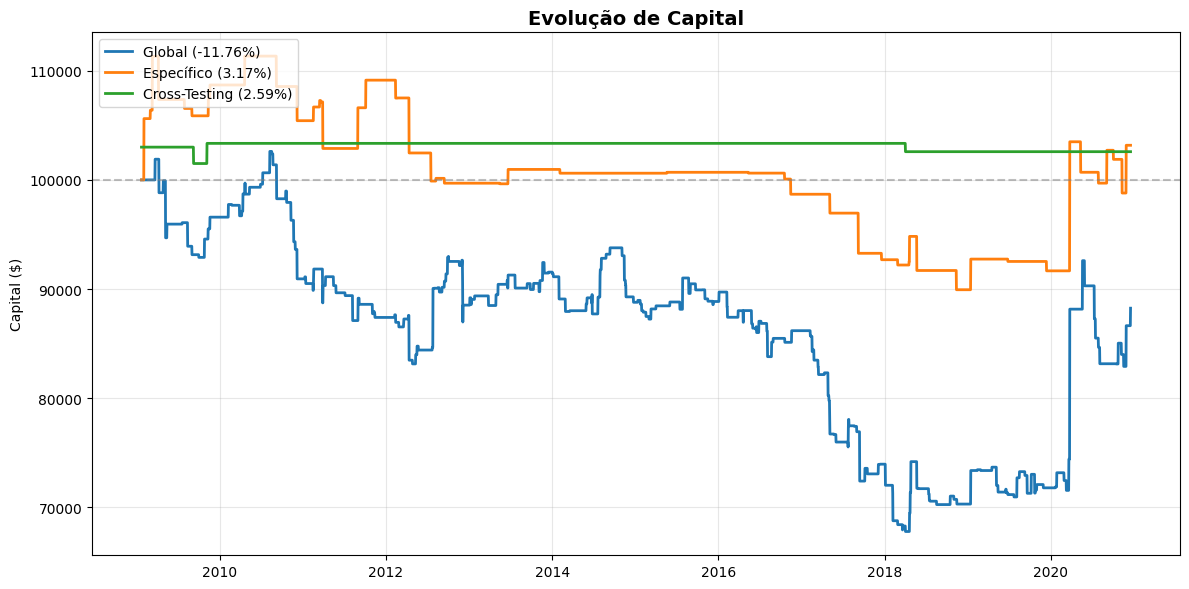

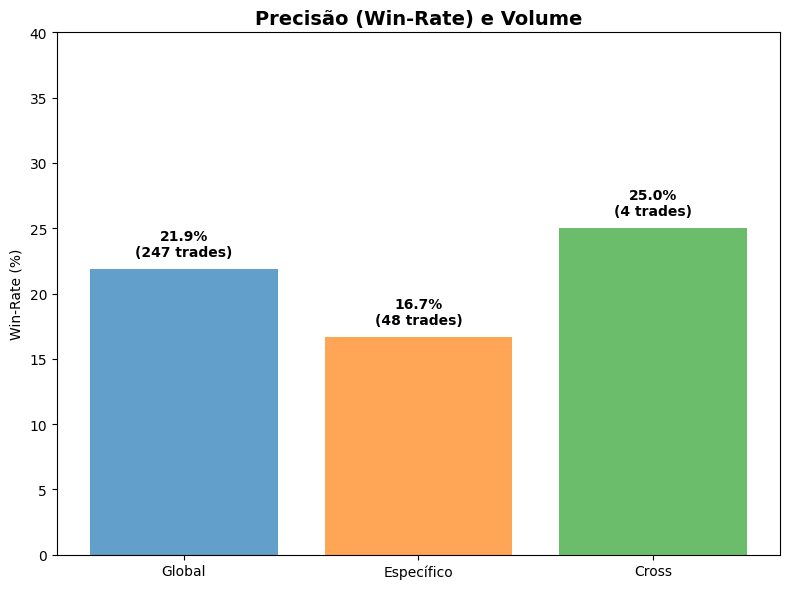

-> Gráficos guardados separadamente em: ../results/Train_2022-01-01_to_2025-12-31__Test_2008-01-01_to_2020-12-31/comparison_equity.png e comparison_winrate.png

=== A GERAR GRÁFICOS INDIVIDUAIS DE ENTRADA/SAÍDA ===
-> 13 gráficos de pares detalhados guardados na pasta: ../results/Train_2022-01-01_to_2025-12-31__Test_2008-01-01_to_2020-12-31/graficos_trades_Global/
-> 3 gráficos de pares detalhados guardados na pasta: ../results/Train_2022-01-01_to_2025-12-31__Test_2008-01-01_to_2020-12-31/graficos_trades_Especifico/
-> 2 gráficos de pares detalhados guardados na pasta: ../results/Train_2022-01-01_to_2025-12-31__Test_2008-01-01_to_2020-12-31/graficos_trades_Cross/


In [139]:
print("\n=== ANÁLISE COMPARATIVA SOTA (TRÊS ABORDAGENS) ===")
# Passamos os 3 DataFrames
io.compare_strategies(trades_global, trades_specific, trades_cross, cfg.CAPITAL_INICIAL, save_dir)

print("\n=== A GERAR GRÁFICOS INDIVIDUAIS DE ENTRADA/SAÍDA ===")
io.generate_trade_plots(trades_global, spreads_dict, save_dir, model_name="Global")
io.generate_trade_plots(trades_specific, spreads_dict, save_dir, model_name="Especifico")
io.generate_trade_plots(trades_cross, spreads_dict, save_dir, model_name="Cross")